<img src="https://github.com/KartikNW/MSDS_458_Public/blob/main/images2/NorthwesternHeader.png?raw=1" />

In [ ]:
NOTEBOOK_VERSION = "3.0"
QUARTER = "Spring 2026"

from datetime import datetime
NOTEBOOK_START_TIME = datetime.now()
print(f"Notebook Version: {NOTEBOOK_VERSION} | {QUARTER}")

Notebook Version: 3.0 | Spring 2026


# Assignment 02 – Part 2: t-SNE Visualization of CNN Representations

In this notebook, we build the **same CNN architecture** from Part 1, train it on the CIFAR-10 dataset, and then use **t-SNE (t-distributed Stochastic Neighbor Embedding)** to visualize how the network's hidden layers represent different image classes.

The key idea is to extract **activations from the dense layer** (the network's learned representations) and reduce them to 2 dimensions using t-SNE. This reveals how well the CNN separates the 10 CIFAR-10 classes in its internal feature space.

By the end of this notebook, you will understand:

- How to extract **hidden layer activations** from a trained CNN
- How **t-SNE** works as a dimensionality reduction technique for visualization
- How to interpret t-SNE scatter plots to assess model quality and class separability

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

- Train a CNN on CIFAR-10 and extract **intermediate layer representations**
- Apply **t-SNE** to high-dimensional activations for 2D visualization
- Interpret t-SNE scatter plots to assess how well the CNN separates classes
- Understand the relationship between **model accuracy** and **cluster separation** in the embedding space
- Overlay actual images onto the t-SNE plot for richer interpretation

## Notebook Overview

1. 🧩 Step 1: Setup and Imports
2. ✅ Step 2: Version Requirements
3. 🗂️ Step 3: Load the CIFAR-10 Dataset
4. 🔧 Step 4: Data Preprocessing
5. 🏗️ Step 5: Build and Train CNN Model
6. 📊 Step 6: Evaluate the Model
7. 🔬 Step 7: Extract Hidden Layer Activations
8. 📉 Step 8: t-SNE Dimensionality Reduction and Visualization
9. 🎓 Summary

## 🧩 Step 1: Setup and Imports

Import all necessary libraries for data handling, visualization, CNN modeling, and t-SNE dimensionality reduction.

In [ ]:
import time
import numpy as np
import pandas as pd
from packaging import version
from collections import Counter

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error as MSE
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models, layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, BatchNormalization, Dropout, Flatten, Input, Dense
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import to_categorical
import tensorflow.keras.backend as k

In [ ]:
%matplotlib inline
np.set_printoptions(precision=3, suppress=True)

## ✅ Step 2: Version Requirements

This assignment requires recent versions of **Python** and **TensorFlow/Keras** to ensure compatibility with the CNN code.

| Library | Minimum Version | Purpose |
|---------|----------------|---------|
| Python | 3.9+ | Core language |
| TensorFlow | 2.0+ | Deep learning framework |
| scikit-learn | 1.0+ | t-SNE, metrics, and train/test split |
| NumPy | 1.21+ | Numerical operations |
| Matplotlib | 3.5+ | Visualization |
| Seaborn | 0.11+ | Statistical visualization |

In [ ]:
print("This notebook requires TensorFlow 2.0 or above")
print("TensorFlow version: ", tf.__version__)
assert version.parse(tf.__version__).release[0] >=2

This notebook requires TensorFlow 2.0 or above
TensorFlow version:  2.19.0


## 🗂️ Step 3: Load the CIFAR-10 Dataset

The CIFAR-10 dataset consists of 60,000 32×32 colour images in 10 classes, with 6,000 images per class. There are 50,000 training images and 10,000 test images.

The dataset is divided into five training batches and one test batch, each with 10,000 images. The test batch contains exactly 1,000 randomly-selected images from each class. The training batches contain the remaining images in random order, but some training batches may contain more images from one class than another. Between them, the training batches contain exactly 5,000 images from each class.

> 📖 **Reference**: [The CIFAR-10 dataset](https://www.cs.toronto.edu/~kriz/cifar.html)

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


* Tuple of Numpy arrays: (x_train, y_train), (x_test, y_test).
* x_train, x_test: uint8 arrays of color image data with shapes (num_samples, 32, 32).
* y_train, y_test: uint8 arrays of digit labels (integers in range 0-9)

## 🔧 Step 4: Data Preprocessing

Define class labels, create a validation split, and normalize pixel values to the [0, 1] range.

The labels are an array of integers, ranging from 0 to 9. These correspond to the class of clothing the image represents:

|Label  |Class_  |
|-------|--------|
|0|	airplane     |
|1|	automobile   |
|2|	bird         |
|3|	cat          |
|4|	deer         |
|5|	dog          |
|6|	frog         |
|7|	horse        |
|8|	ship         |
|9|	truck        |

In [ ]:
class_names = ['airplane'
,'automobile'
,'bird'
,'cat'
,'deer'
,'dog'
,'frog'
,'horse'
,'ship'
,'truck']

### Create Validation Data Set

In [ ]:
x_train_split, x_valid_split, y_train_split, y_valid_split = train_test_split(x_train
                                                                              ,y_train
                                                                              ,test_size=.1
                                                                              ,random_state=42
                                                                              ,shuffle=True)

### Confirm Datasets {Train, Validation, Test}

In [ ]:
print(x_train_split.shape, x_valid_split.shape, x_test.shape)

(45000, 32, 32, 3) (5000, 32, 32, 3) (10000, 32, 32, 3)


### Rescale Examples {Train, Validation, Test}

The images are 32×32 NumPy arrays, with pixel values ranging from 0 to 255.

1. Each element in each example is a pixel value
2. Pixel values range from 0 to 255
3. 0 = black
4. 255 = white

In [ ]:
x_train_norm = x_train_split/255
x_valid_norm = x_valid_split/255
x_test_norm = x_test/255

## 🏗️ Step 5: Build and Train CNN Model

<img src="https://github.com/KartikNW/MSDS_458_Public/blob/main/images2/CNN_architecture_v4.png?raw=1" width="800" >

We use a `Sequential` class defined in Keras to create our model. The first 9 layers (Conv2D, MaxPooling, Dropout) handle **feature learning**. The last 3 layers handle **classification**.

### Define Helper Functions

These utility functions handle model compilation/training, training curve visualization, classification reporting, and confusion matrix plotting.

In [ ]:
def compile_train_model(model, x_train, y_train, x_valid, y_valid, epochs=200):
  timestamp=int(time.time())

  # Compile
  model.compile(optimizer='rmsprop',
                loss = 'SparseCategoricalCrossentropy',
                metrics=['accuracy'])

  # Train
  start_time = time.time()
  history = model.fit(
    x_train,
    y_train,
    epochs=epochs,
    batch_size=512,
    validation_data=(x_valid, y_valid),
    #verbose=0,
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint("CNN_model.keras",save_best_only=True,save_weights_only=False)
        ,tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3)
        ]
  )
  end_time = time.time()
  second_elapsed = round(end_time - start_time)

  print(f'Finished model training in {second_elapsed}s')

  print('Model performance with training set')
  model.evaluate(x_train, y_train)

  print('Evaluating model performance with validation set')
  model.evaluate(x_valid, y_valid)

  return history, model

In [ ]:
def plot_history(history):
  losses = history.history['loss']
  accs = history.history['accuracy']
  val_losses = history.history['val_loss']
  val_accs = history.history['val_accuracy']
  epochs = len(losses)

  plt.figure(figsize=(16, 4))
  for i, metrics in enumerate(zip([losses, accs], [val_losses, val_accs], ['Loss', 'Accuracy'])):
    plt.subplot(1, 2, i + 1)
    plt.plot(range(epochs), metrics[0], label='Training {}'.format(metrics[2]))
    plt.plot(range(epochs), metrics[1], label='Validation {}'.format(metrics[2]))
    plt.legend()
  plt.show()

def display_training_curves(training, validation, title, subplot):
  ax = plt.subplot(subplot)
  ax.plot(training)
  ax.plot(validation)
  ax.set_title('model '+ title)
  ax.set_ylabel(title)
  ax.set_xlabel('epoch')
  ax.legend(['training', 'validation'])

In [ ]:
def print_validation_report(y_test, predictions):
    print("Classification Report")
    print(classification_report(y_test, predictions))
    print('Accuracy Score: {}'.format(accuracy_score(y_test, predictions)))
    print('Root Mean Square Error: {}'.format(np.sqrt(MSE(y_test, predictions))))

In [ ]:
def plot_confusion_matrix(y_true, y_pred):
    mtx = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(16,12))
    sns.heatmap(mtx, annot=True, fmt='d', linewidths=.75,  cbar=False, ax=ax,cmap='Blues',linecolor='white')
    #  square=True,
    plt.ylabel('true label')
    plt.xlabel('predicted label')

### Build CNN Architecture

In [ ]:
# ======================================================================
# CNN Architecture — EXPERIMENT HERE: try different filters, units, dropout
# ======================================================================
k.clear_session()
model = Sequential([
  Conv2D(filters=128, kernel_size=(3, 3), strides=(1, 1), activation=tf.nn.relu,input_shape=x_train_norm.shape[1:]),  # --- EXPERIMENT HERE: try 64, 128, 256 filters ---
  MaxPool2D((2, 2),strides=2),
  Dropout(0.3),  # --- EXPERIMENT HERE: try 0.2, 0.3, 0.5 ---
  Conv2D(filters=256, kernel_size=(3, 3), strides=(1, 1), activation=tf.nn.relu),  # --- EXPERIMENT HERE: try different filter counts ---
  MaxPool2D((2, 2),strides=2),
  Dropout(0.3),
  Conv2D(filters=512, kernel_size=(3, 3), strides=(1, 1), activation=tf.nn.relu),  # --- EXPERIMENT HERE: try different filter counts ---
  MaxPool2D((2, 2),strides=2),
  Dropout(0.3),
  Flatten(),
  Dense(units=384,activation=tf.nn.softmax,kernel_regularizer=tf.keras.regularizers.L2(0.001)),  # --- EXPERIMENT HERE: try 128, 256, 512 units ---
  BatchNormalization(),
  Dropout(0.3),
  Dense(units=10, activation=tf.nn.softmax)
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 384)            │       786,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 384)            │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         3,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,271,114 (8.66 MB)

 Trainable params: 2,270,346 (8.66 MB)

 Non-trainable params: 768 (3.00 KB)

### Compile and Train

In [ ]:
# --- EXPERIMENT HERE: try different epochs, batch_size, optimizer ('adam', 'rmsprop', 'sgd') ---
# Compile and train
history, model = compile_train_model(model,
                                     x_train_norm, y_train_split,
                                     x_valid_norm, y_valid_split
                                    )

Epoch 1/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 34s 235ms/step - accuracy: 0.2162 - loss: 2.5013 - val_accuracy: 0.1434 - val_loss: 2.4879
Epoch 2/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.3569 - loss: 1.9148 - val_accuracy: 0.1508 - val_loss: 2.3171
Epoch 3/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - accuracy: 0.4376 - loss: 1.6341 - val_accuracy: 0.3030 - val_loss: 2.1303
Epoch 4/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.4916 - loss: 1.4700 - val_accuracy: 0.3230 - val_loss: 2.0598
Epoch 5/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - accuracy: 0.5330 - loss: 1.3610 - val_accuracy: 0.5048 - val_loss: 1.7253
Epoch 6/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - accuracy: 0.5729 - loss: 1.2676 - val_accuracy: 0.4352 - val_loss: 1.6177
Epoch 7/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - accuracy: 0.5990 - loss: 1.1914 - val_accuracy: 0.6078 - val_loss: 1.2544
Epoch 8/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - accuracy: 0.6281 - loss: 1.1256 - val_accuracy: 

## 📊 Step 6: Evaluate the Model

Plot training metrics and evaluate on the test set using a confusion matrix and classification report.

### Plotting Performance Metrics

We use Matplotlib to create 2 plots--displaying the training and validation loss (resp. accuracy) for each (training) epoch side by side.

In [ ]:
history_dict = history.history
history_dict.keys()
history_df=pd.DataFrame(history_dict)

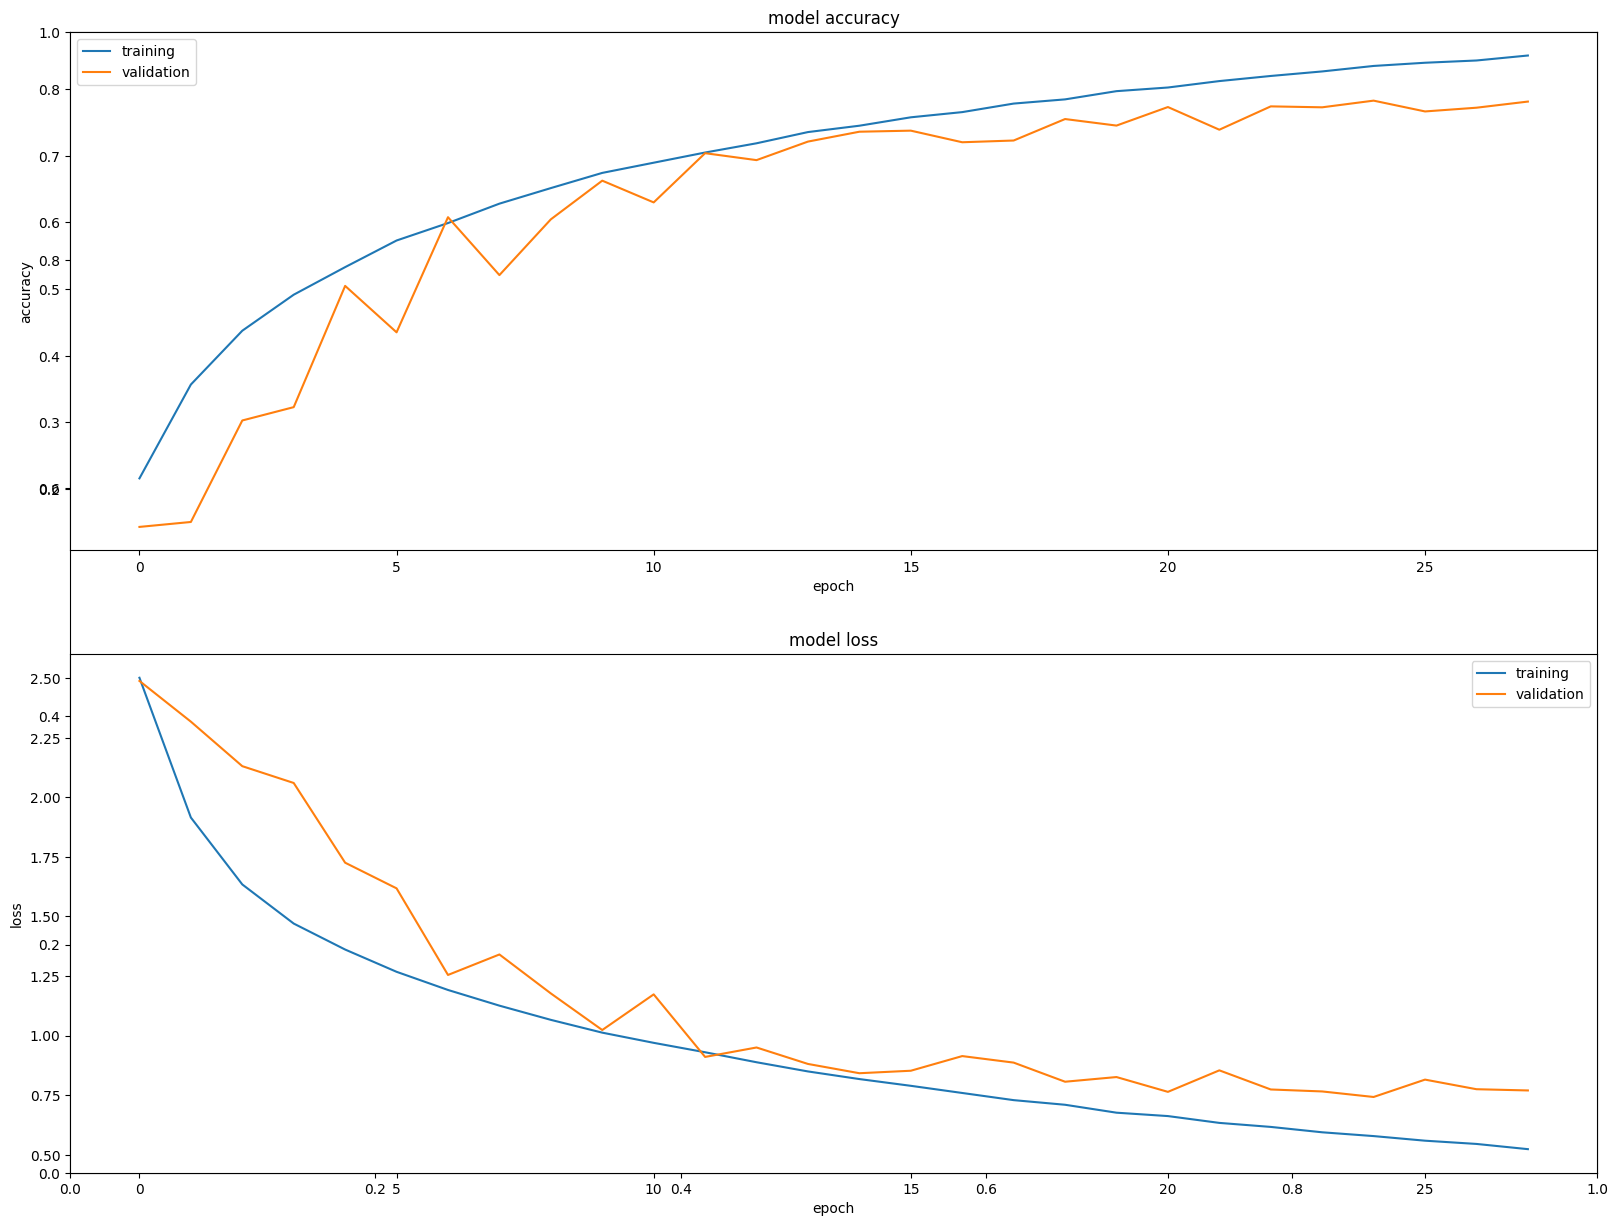

In [ ]:
plt.subplots(figsize=(16,12))
plt.tight_layout()
display_training_curves(history_df['accuracy'], history_df['val_accuracy'], 'accuracy', 211)
display_training_curves(history_df['loss'], history_df['val_loss'], 'loss', 212)

### Confusion Matrix

Using `sklearn.metrics`. Then we visualize the confusion matrix and see what that tells us.

In [ ]:
pred1= model.predict(x_test_norm)
pred1=np.argmax(pred1, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [ ]:
print_validation_report(y_test, pred1)

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1000
           1       0.86      0.89      0.87      1000
           2       0.88      0.50      0.64      1000
           3       0.56      0.68      0.62      1000
           4       0.68      0.81      0.74      1000
           5       0.81      0.56      0.66      1000
           6       0.75      0.87      0.81      1000
           7       0.80      0.83      0.82      1000
           8       0.81      0.91      0.86      1000
           9       0.83      0.86      0.85      1000

    accuracy                           0.77     10000
   macro avg       0.78      0.77      0.77     10000
weighted avg       0.78      0.77      0.77     10000

Accuracy Score: 0.7711
Root Mean Square Error: 1.951742810925661


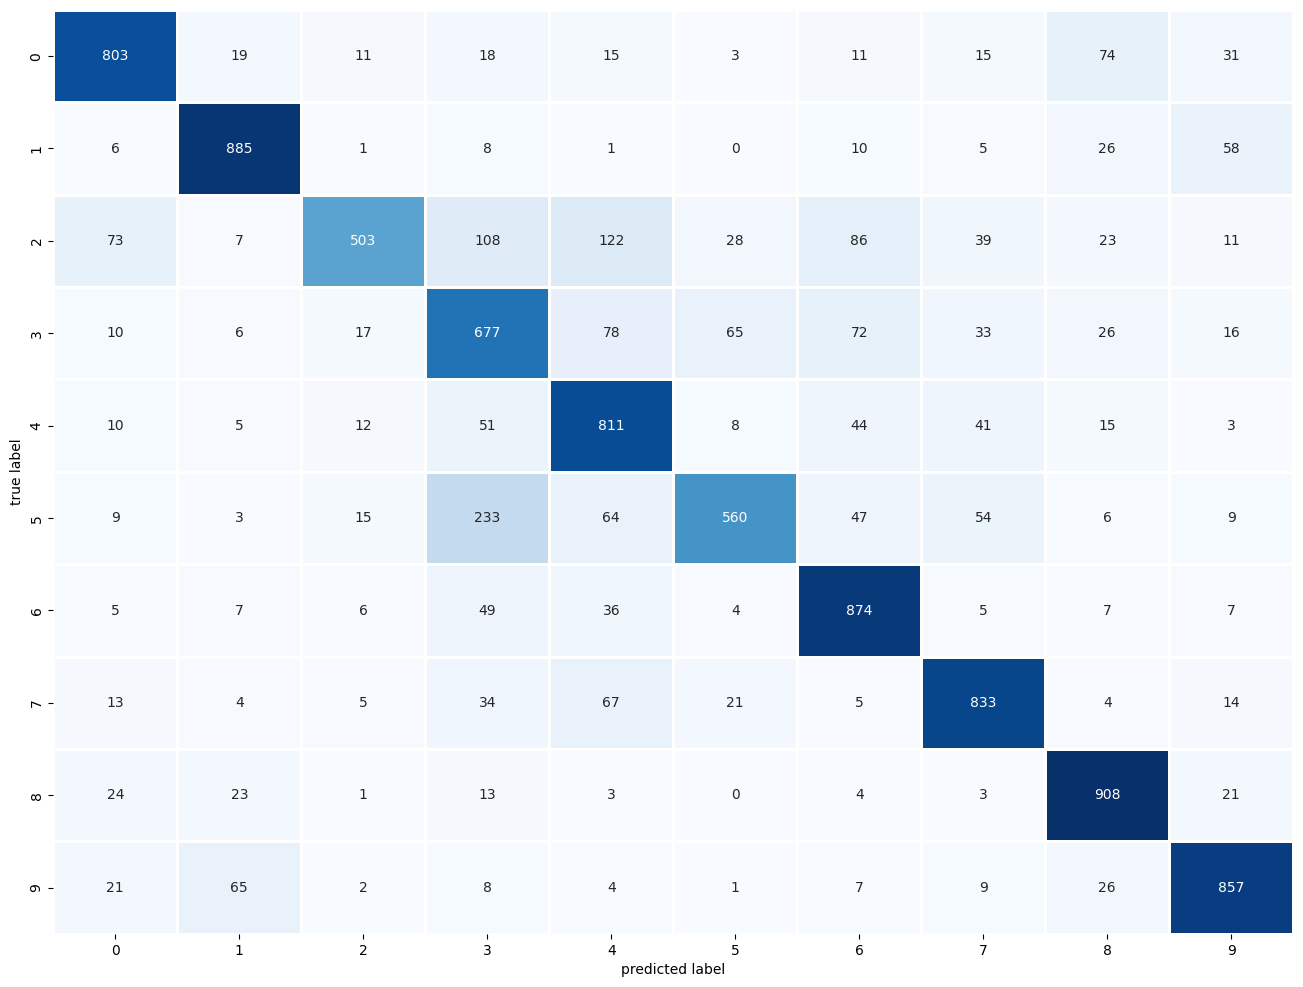

In [ ]:
plot_confusion_matrix(y_test,pred1)

## 🔬 Step 7: Extract Hidden Layer Activations

Extract the **dense layer activations** (384-dimensional) from the trained CNN. These activations represent how the network "sees" each image — a compressed, learned representation of the input.

In [ ]:
# Extracts the outputs of all layers:
layer_outputs = [layer.output for layer in model.layers]

# Creates a model that will return these outputs, given the model input:
activation_model = models.Model(inputs=model.inputs, outputs=layer_outputs)

# Get activation values for the last dense layer
activations = activation_model.predict(x_valid_norm[:2000])
dense_layer_activations = activations[-3]
output_layer_activations = activations[-1]

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


## 📉 Step 8: t-SNE Dimensionality Reduction and Visualization

Apply **t-SNE** to reduce the 384-dimensional dense layer activations to 2 dimensions for visualization.
t-SNE preserves local structure, so nearby points in the high-dimensional space remain close in the 2D embedding.

> 📖 **Reference**: [sklearn.manifold.TSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)

In [ ]:
# --- EXPERIMENT HERE: try different perplexity (5, 30, 50), max_iter (500, 1000), n_components ---
# Reduce the dimension using T-SNE to visualize i n a scatterplot
tsne = TSNE(n_components=2, verbose=1, init='pca', learning_rate='auto', perplexity=40, max_iter=300)
tsne_results = tsne.fit_transform(dense_layer_activations)

# Scaling
tsne_results = (tsne_results - tsne_results.min()) / (tsne_results.max() - tsne_results.min())

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 2000 samples in 0.001s...
[t-SNE] Computed neighbors for 2000 samples in 0.187s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2000
[t-SNE] Computed conditional probabilities for sample 2000 / 2000
[t-SNE] Mean sigma: 1.557374
[t-SNE] KL divergence after 250 iterations with early exaggeration: 69.165398
[t-SNE] KL divergence after 300 iterations: 1.672432


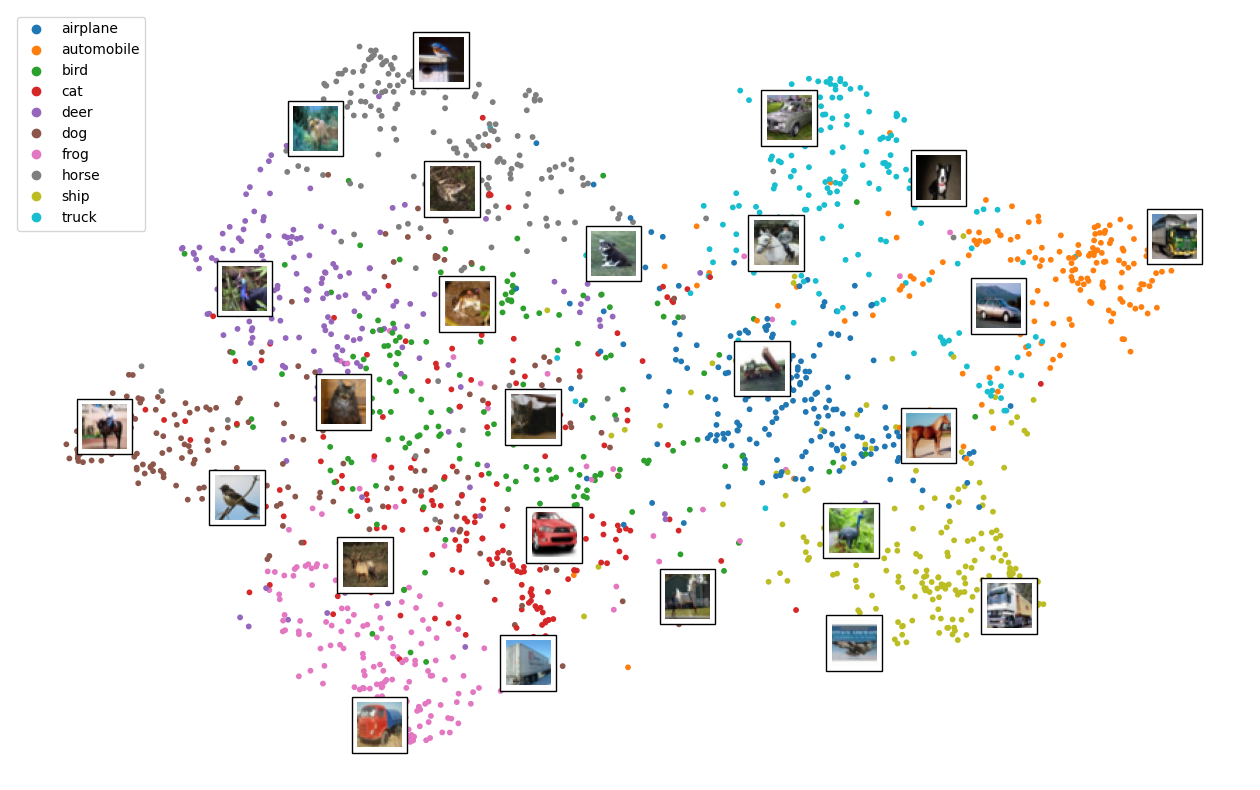

In [ ]:
cmap = plt.cm.tab10
plt.figure(figsize=(16,10))
scatter = plt.scatter(tsne_results[:,0],tsne_results[:,1], c=y_valid_split[:2000], s=10, cmap=cmap)
plt.legend(handles=scatter.legend_elements()[0], labels=class_names)

image_positions = np.array([[1., 1.]])
for index, position in enumerate(tsne_results):
    dist = np.sum((position - image_positions) ** 2, axis=1)
    if np.min(dist) > 0.02: # if far enough from other images
        image_positions = np.r_[image_positions, [position]]
        imagebox = mpl.offsetbox.AnnotationBbox(
            mpl.offsetbox.OffsetImage(x_train[index], cmap="binary"),
            position, bboxprops={"lw": 1})
        plt.gca().add_artist(imagebox)
plt.axis("off")
plt.show()

### 💡 Suggestions for Further Exploration
- Try **different perplexity values** (5, 30, 50, 100) and observe how cluster shapes change
- Increase **n_iter** to 1000 or 2000 for better convergence
- Compare t-SNE embeddings from **different layers** (e.g., after the first Conv block vs. the dense layer)
- Try **UMAP** as an alternative to t-SNE — it often preserves both local and global structure better
- Color points by **prediction correctness** (green = correct, red = incorrect) to see where the model struggles

## 🎓 Summary

In this notebook, you:

1. Built and trained the **same CNN architecture** from Part 1 using a different optimizer (RMSprop) and batch size
2. Evaluated model performance using **confusion matrices** and **classification reports**
3. Extracted **hidden layer activations** from the dense layer of the trained CNN
4. Applied **t-SNE** to reduce 384-dimensional activations to 2D for visualization
5. Created an **annotated scatter plot** showing how the CNN separates the 10 CIFAR-10 classes in its learned feature space

**Key Insight**: Well-separated clusters in the t-SNE plot correspond to classes the model classifies accurately. Overlapping clusters indicate classes the model confuses — which should align with the confusion matrix from Step 6.

In [ ]:
NOTEBOOK_END_TIME = datetime.now()
elapsed = NOTEBOOK_END_TIME - NOTEBOOK_START_TIME
total_mins, total_secs = divmod(int(elapsed.total_seconds()), 60)
print(f"✅ Notebook complete | Version: {NOTEBOOK_VERSION} | {QUARTER}")
print(f"Total time:  {total_mins}m {total_secs}s")
print(f"Current time: {NOTEBOOK_END_TIME.strftime('%Y-%m-%d %H:%M:%S')}")

✅ Notebook complete | Version: 3.0 | Spring 2026
Total time:  4m 24s
Current time: 2026-03-27 07:28:25
